# **Problem Statement :**
To identify which factors products, channels, regions, and customer are driving revenue and profit, and where losses are occurring, in order to optimize business performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_excel('/content/Regional Sales Dataset.xlsx',sheet_name= None)

In [3]:
# Assigning DataFrames to Each Sheet
df_sales = df['Sales Orders']
df_customers = df['Customers']
df_products = df['Products']
df_state_reg = df['State Regions']
df_regions = df['Regions']
df_budgets = df['2017 Budgets']

In [4]:
df_sales.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270


In [5]:
print("df_sales shape: ", (df_sales.shape))
print("df_customers shape: ", (df_customers.shape))
print("df_products shape: ", (df_products.shape))
print("df_state_reg shape: ", (df_state_reg.shape))
print("df_regions shape: ", (df_regions.shape))
print("df_budgets shape: ", (df_budgets.shape))

df_sales shape:  (64104, 12)
df_customers shape:  (175, 2)
df_products shape:  (30, 2)
df_state_reg shape:  (49, 3)
df_regions shape:  (994, 15)
df_budgets shape:  (30, 2)


In [6]:
df_regions.head()

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago
2,3,Decatur,Limestone County/Morgan County,AL,Alabama,City,34.57332,-86.99214,256,55437,22294,41496,141006257,17594716,America/Chicago
3,4,Dothan,Dale County/Houston County/Henry County,AL,Alabama,City,31.23370,-85.40682,334,68567,25913,42426,232166237,835468,America/Chicago
4,5,Hoover,Shelby County/Jefferson County,AL,Alabama,City,33.37695,-86.80558,205,84848,32789,77146,122016784,2553332,America/Chicago


In [7]:
df_budgets.head()

,Product Name,2017 Budgets
0,Product 1,3016489.209
1,Product 2,3050087.565
2,Product 3,2642352.432
3,Product 4,2885560.824
4,Product 5,3925424.542


In [8]:
df_customers.head()

,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp
4,5,Blogtags Ltd


In [9]:
df_products.head()

,Index,Product Name
0,1,Product 1
1,2,Product 2
2,3,Product 3
3,4,Product 4
4,5,Product 5


In [10]:
df_state_reg.head()

,Column1,Column2,Column3
0,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South
3,AZ,Arizona,West
4,CA,California,West


In [11]:
new_header = df_state_reg.iloc[0]
df_state_reg.columns = new_header
df_state_reg = df_state_reg[1:].reset_index(drop=True)
df_state_reg.head()

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


In [12]:
df_sales.isnull().sum()

,0
OrderNumber,0
OrderDate,0
Customer Name Index,0
Channel,0
Currency Code,0
Warehouse Code,0
Delivery Region Index,0
Product Description Index,0
Order Quantity,0
Unit Price,0


In [13]:
df_customers.isnull().sum()

,0
Customer Index,0
Customer Names,0


In [14]:
df_state_reg.isnull().sum()

,0
0,
State Code,0
State,0
Region,0


In [15]:
df_regions.isnull().sum()

,0
id,0
name,0
county,0
state_code,0
state,0
type,0
latitude,0
longitude,0
area_code,0
population,0


In [16]:
df_budgets.isnull().sum()

,0
Product Name,0
2017 Budgets,0


#### **Data Cleaning and Wrangling**

In [17]:
# Merge with customers
df = df_sales.merge(df_customers, how ='left', left_on='Customer Name Index', right_on='Customer Index')

In [18]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group


In [19]:
# Merge with Products
df = df.merge(df_products, how ='left', left_on='Product Description Index', right_on='Index')

In [20]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names,Index,Product Name
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd,27,Product 27
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd,20,Product 20
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp,26,Product 26
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group,7,Product 7
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group,8,Product 8


In [21]:
# Merge with Regions
df = df.merge(df_regions, how ='left', left_on='Delivery Region Index', right_on='id')

In [22]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,City,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,City,39.61366,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,City,37.66243,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,City,39.16533,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,Town,41.77524,-72.52443,959,58007,24141,63158,70972793,720300,America/New York


In [23]:
# Merge with State Regions
df = df.merge(df_state_reg[["State Code", "Region"]], how ='left', left_on='state_code', right_on='State Code')

In [24]:
# Merge with Budgets
df = df.merge(df_budgets, how ='left', on='Product Name')

In [25]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,912,145674,52798,36466,268318796,13908113,America/New York,GA,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast,1085037.329


In [26]:
df.to_csv('file.csv')

In [27]:
# Clean up redundant Columns
cols_to_drop = ['Customer Index','Index', 'id', 'State Code']
df = df.drop(columns = cols_to_drop, errors='ignore')
cols_to_drop = ['state code_y','region_y','']
df = df.drop(columns = cols_to_drop, errors='ignore')

In [28]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,Northeast,1085037.329


In [29]:
# Converting all columns to lower case for consistency and easier access
df.columns = df.columns.str.lower()
df.columns.values

array(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer names', 'product name',
       'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households',
       'median_income', 'land_area', 'water_area', 'time_zone', 'region',
       '2017 budgets'], dtype=object)

In [30]:
# Keep the Important Columns and Delete the Unnecessary Columns
cols_to_keep = [
    'ordernumber',
    'orderdate',
    'customer names',
    'channel',
    'product name',
    'order quantity',
    'unit price',
    'line total',
    'total unit cost',
    'state_code',
    'county',
    'state',
    'region',
    'latitude',
    'longitude',
    '2017 budgets'

]


In [31]:
df = df[cols_to_keep]
df.head()

,ordernumber,orderdate,customer names,channel,product name,order quantity,unit price,line total,total unit cost,state_code,county,state,region,latitude,longitude,2017 budgets
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,964940.231
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,2067108.120
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,5685138.270
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,889737.555
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,1085037.329


In [32]:
# Rename the Columns
df = df.rename(columns={
    'ordernumber'      : 'order_number',
    'orderdate'        : 'order_date',
    'customer names'   : 'customer_name',
    'product name'     : 'product_name',
    'order quantity'   : 'quantity',
    'unit price'       : 'unit_price',
    'line total'       : 'revenue',
    'total unit cost'  : 'cost',
    'state_code'       : 'state',
    'state'            : 'state_name',
    'region'           : 'us_region',
    'latitude'         : 'lat',
    'longitude'        : 'lon',
    '2017 budgets'     : 'budget'
    }
               )

In [33]:
df.head(1)

,order_number,order_date,customer_name,channel,product_name,quantity,unit_price,revenue,cost,state,county,state_name,us_region,lat,lon,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,964940.231


In [34]:
# Blank Out budgets for non-2017 orders
df.loc[df['order_date'].dt.year != 2017, 'budget'] = pd.NA
df[['order_date','product_name', 'revenue','budget']]

,order_date,product_name,revenue,budget
0,2014-01-01,Product 27,14994.6,NaN
1,2014-01-01,Product 20,25868.7,NaN
2,2014-01-01,Product 26,5869.2,NaN
3,2014-01-01,Product 7,16368.1,NaN
4,2014-01-01,Product 8,18331.2,NaN
...,...,...,...,...
64099,2018-02-28,Product 26,21788.4,NaN
64100,2018-02-28,Product 21,5185.8,NaN
64101,2018-02-28,Product 13,43483.0,NaN
64102,2018-02-28,Product 20,27717.9,NaN


In [35]:
df.to_csv('final.csv')

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_number   64104 non-null  object        
 1   order_date     64104 non-null  datetime64[ns]
 2   customer_name  64104 non-null  object        
 3   channel        64104 non-null  object        
 4   product_name   64104 non-null  object        
 5   quantity       64104 non-null  int64         
 6   unit_price     64104 non-null  float64       
 7   revenue        64104 non-null  float64       
 8   cost           64104 non-null  float64       
 9   state          64104 non-null  object        
 10  county         64104 non-null  object        
 11  state_name     64104 non-null  object        
 12  us_region      64104 non-null  object        
 13  lat            64104 non-null  float64       
 14  lon            64104 non-null  float64       
 15  budget         1526

In [37]:
# Filtering the Dataset to include only records from 2017
df_2017 = df[df['order_date'].dt.year == 2017]
df.isnull().sum()

,0
order_number,0
order_date,0
customer_name,0
channel,0
product_name,0
quantity,0
unit_price,0
revenue,0
cost,0
state,0


In [38]:
df_2017.head()

,order_number,order_date,customer_name,channel,product_name,quantity,unit_price,revenue,cost,state,county,state_name,us_region,lat,lon,budget
46363,SO - 0002544,2017-01-01,NCS Group,Wholesale,Product 30,6,1239.5,7437.0,1028.785,NJ,Hudson County,New Jersey,Northeast,40.77955,-74.02375,1011609.684
46364,SO - 0006431,2017-01-01,Epic Group,Wholesale,Product 13,5,1829.1,9145.5,1207.206,CO,Mesa County,Colorado,West,39.06387,-108.55065,3720639.645
46365,SO - 0007491,2017-01-01,State Ltd,Wholesale,Product 15,9,2412.0,21708.0,1664.280,CA,Los Angeles County,California,West,33.96168,-118.35313,3299478.315
46366,SO - 0008741,2017-01-01,Fivebridge Ltd,Wholesale,Product 8,8,904.5,7236.0,750.735,IA,Dubuque County,Iowa,Midwest,42.50056,-90.66457,1085037.329
46367,SO - 0009295,2017-01-01,Tagfeed Ltd,Wholesale,Product 2,12,1112.2,13346.4,811.906,FL,Hernando County,Florida,South,28.47689,-82.52546,3050087.565


In [39]:
df['total_cost'] = df['quantity'] * df['cost']

In [40]:
df['profit'] = df['revenue'] - df['total_cost']
df['profit_margin'] = df['profit'] / df['revenue']*100

In [41]:
df.head()

,order_number,order_date,customer_name,channel,product_name,quantity,unit_price,revenue,cost,state,county,state_name,us_region,lat,lon,budget,total_cost,profit,profit_margin
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,NaN,10946.058,4048.542,27.0
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,NaN,13969.098,11899.602,46.0
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,NaN,4108.440,1760.760,30.0
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,NaN,7201.964,9166.136,56.0
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,NaN,10082.160,8249.040,45.0


#**Exploratory Data Analysis  (EDA)**

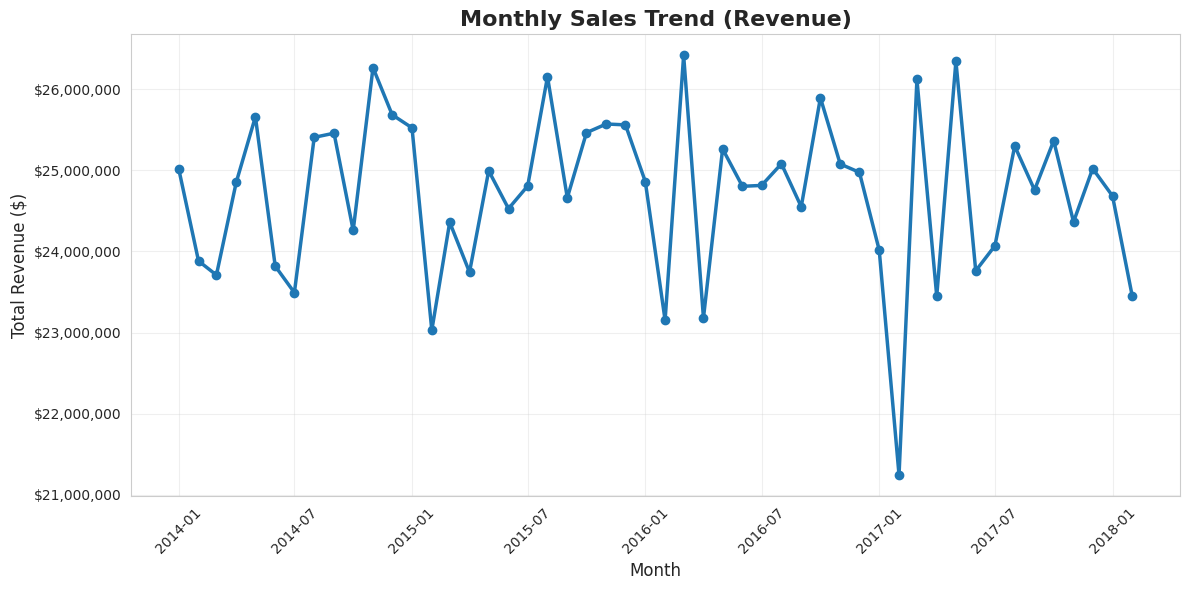

In [42]:
# Monthly Sales Trend Over Time

df['order_date'] = pd.to_datetime(df['order_date'])
df['year_month'] = df['order_date'].dt.to_period('M')

monthly_sales = df.groupby('year_month', as_index=False)['revenue'].sum()
monthly_sales['year_month'] = monthly_sales['year_month'].dt.to_timestamp()

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
plt.plot(monthly_sales['year_month'],
         monthly_sales['revenue'],
         marker='o',
         linewidth=2.5,
         color='#1f77b4')

plt.title('Monthly Sales Trend (Revenue)', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

### INSIGHTS :
Sales consistently cycle between \$24 M and \$26 M, with clear peaks in late spring to early summer (May–June) and troughs each January.  

The overall trend remains stable year over year, reflecting a reliable seasonal demand pattern.  

However, the sharp revenue drop in early 2017 stands out as an outlier, warranting closer investigation into potential causes such as market disruptions or mistimed promotions.  

In [43]:
# Make sure order_date is datetime
# Removing the records from January 2018 and February 201
df['order_date'] = pd.to_datetime(df['order_date'])
8
df_new = df[~((df['order_date'].dt.year == 2018) &
          (df['order_date'].dt.month.isin([1, 2])))]
df = df_new.reset_index(drop=True)
print(f"Data after removing Jan & Feb 2018: {df_new.shape[0]:,} rows")

Data after removing Jan & Feb 2018: 61,626 rows


## **Monthly Sales Trend (All Years Combined)**

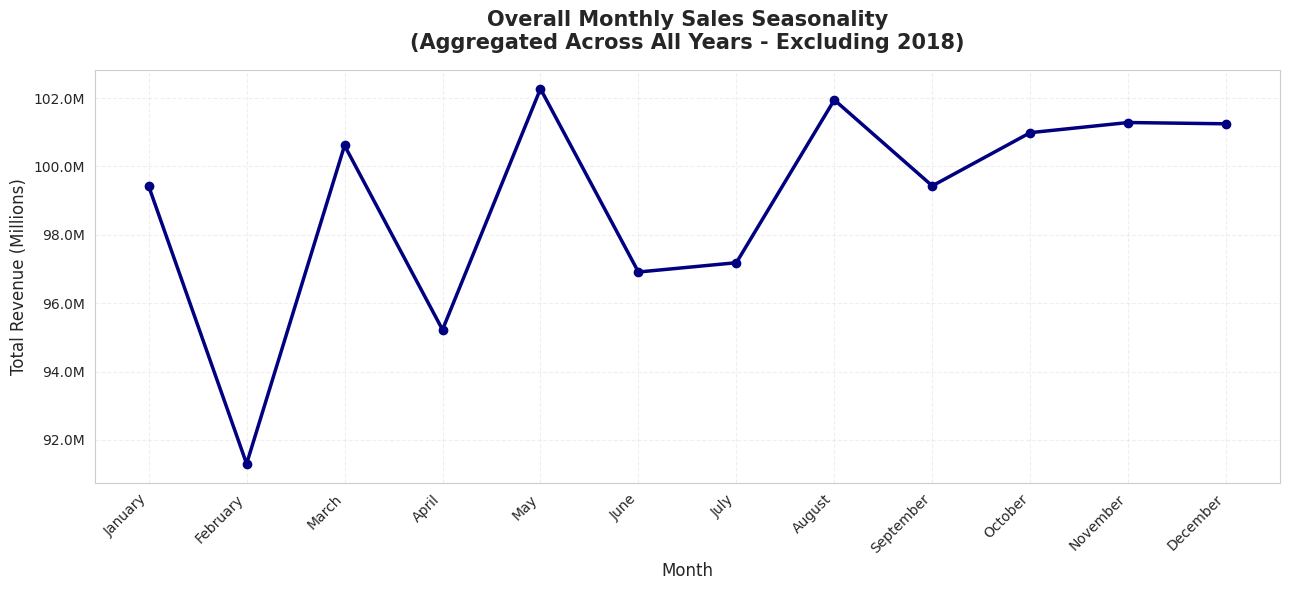

In [44]:

df_ = df[df['order_date'].dt.year != 2018]
# We create df_ so we don’t alter the original df, preserving it intact for other analyses.

df_['order_month_num']  = df_['order_date'].dt.month
df_['order_month_name'] = df_['order_date'].dt.month_name()

monthly_sales = (
    df_
    .groupby(['order_month_num', 'order_month_name'])['revenue']
    .sum()
    .sort_index()
)
#Overall Monthly Sales Seasonality
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(13, 6))

plt.plot(
    monthly_sales.index.get_level_values(1),
    monthly_sales.values,
    marker='o',
    linewidth=2.5,
    color='navy'
)

formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)
plt.title('Overall Monthly Sales Seasonality\n(Aggregated Across All Years - Excluding 2018)',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue (Millions)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

### INSIGHTS

- Across all years, January begins strong with roughly \$99 M, followed by a steep decline through April’s low point (≈\$95 M).

- Sales rebound in May and August (≈\$102 M) before settling into a plateau of \$99–101 M from September to December.

- This pattern reveals a strong post–New Year surge, a spring dip, and a mid–summer bump each calendar year.


## **Top 10 Products by Revenu**

/tmp/ipykernel_4726/132073849.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


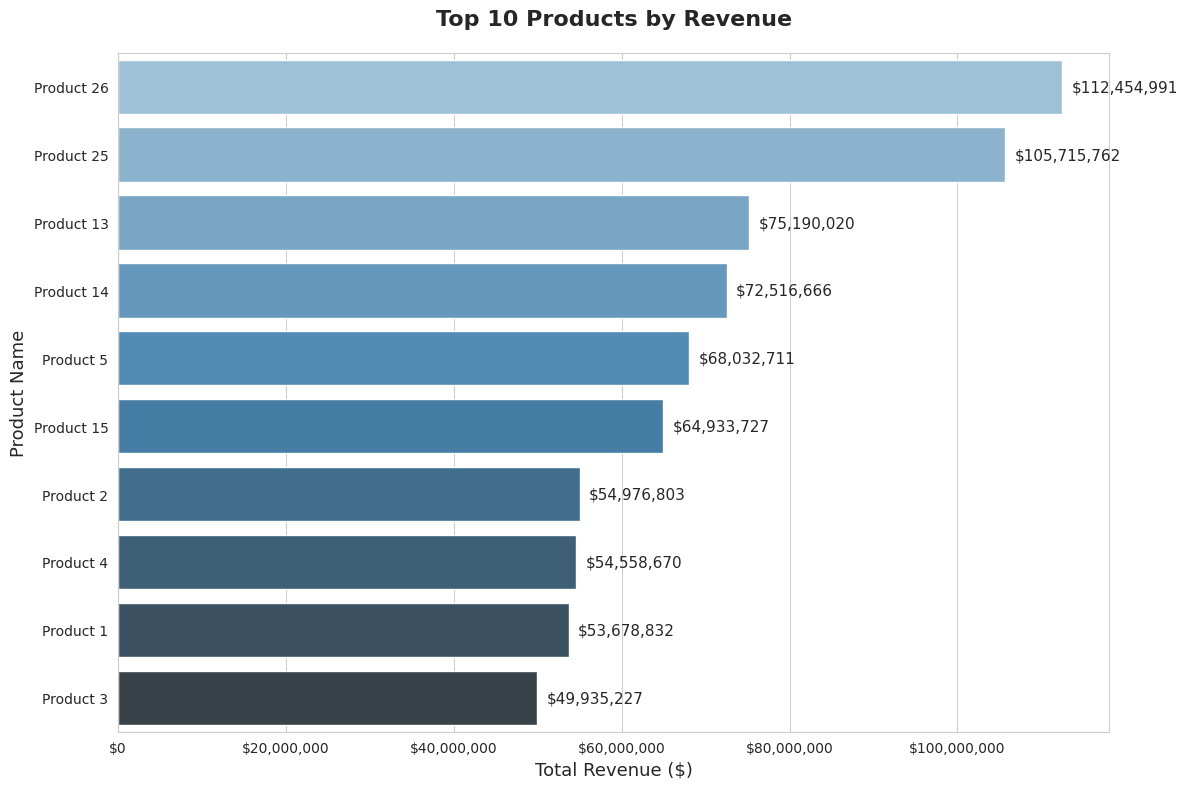

In [45]:
# Top 10 Products by Revenue

top_products = (
    df.groupby('product_name')['revenue']
      .sum()
      .reset_index()
      .sort_values(by='revenue', ascending=False)
      .head(10)
)

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=top_products,
    x='revenue',
    y='product_name',
    palette='Blues_d'
)

for i, v in enumerate(top_products['revenue']):
    ax.text(v + (top_products['revenue'].max() * 0.01), i, f'${v:,.0f}',
            va='center', fontsize=11, fontweight='medium')
plt.title('Top 10 Products by Revenue', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Total Revenue ($)', fontsize=13)
plt.ylabel('Product Name', fontsize=13)

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()


### INSIGHTS
Products 26 and 25 pull away at \$118 M and \$110 M, with a sharp drop to \$78 M for Product 13 and a tight mid-pack at \$68–\$75 M.  

The bottom four cluster at \$52–\$57 M, highlighting similar constraints.  

Focus on growth pilots for the mid-tier and efficiency gains for the lower earners to drive significant lifts.  

## **Sales by Channel**

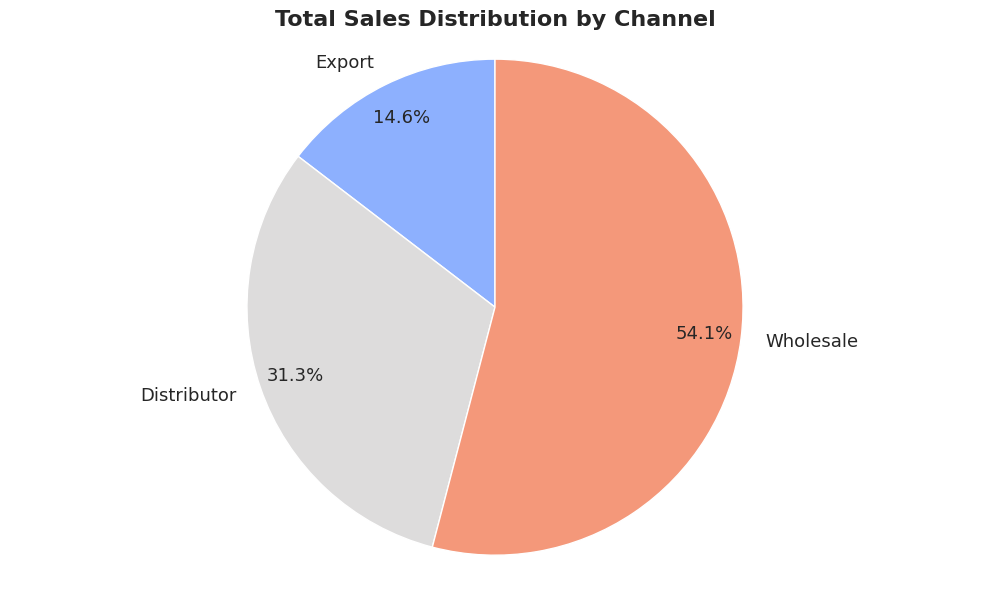

In [46]:

chan_sales = df.groupby('channel')['revenue'].sum().sort_values(ascending=True)
plt.figure(figsize=(10, 6))

colors = sns.color_palette('coolwarm', n_colors=len(chan_sales))

plt.pie(
    chan_sales.values,
    labels=chan_sales.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.85,
    textprops={'fontsize': 13}
)

plt.title('Total Sales Distribution by Channel', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

### INSIGHTS :
Wholesale accounts for 54 % of sales, with distributors at ~31 % and exports at ~15 %, underscoring reliance on domestic bulk channels.  

To diversify revenue and mitigate concentration risk, prioritize expanding export initiatives—through targeted overseas marketing and strategic partner relationships.  


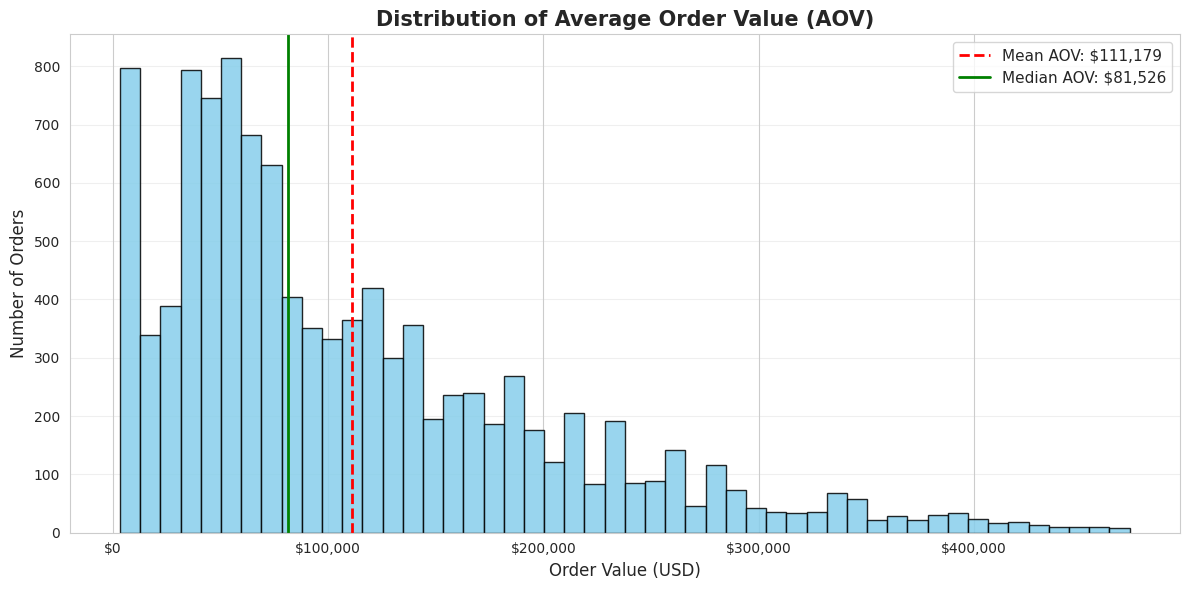

In [47]:
# Avegrage Order Value Distribution
aov = df.groupby('order_number')['revenue'].sum()
plt.figure(figsize=(12, 6))

# Plot the histogram
plt.hist(
    aov,
    bins=50,
    color='skyblue',
    edgecolor='black',
    alpha=0.85
)

plt.title('Distribution of Average Order Value (AOV)',
          fontsize=15,
          fontweight='bold')
plt.xlabel('Order Value (USD)', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
from matplotlib.ticker import FuncFormatter
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))
mean_aov = aov.mean()
median_aov = aov.median()

plt.axvline(mean_aov, color='red', linestyle='--', linewidth=2,
            label=f'Mean AOV: ${mean_aov:,.0f}')
plt.axvline(median_aov, color='green', linestyle='-', linewidth=2,
            label=f'Median AOV: ${median_aov:,.0f}')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


### INSIGHTS
- The order‐value distribution is heavily right‐skewed, with most orders clustering between \$20 K and \$120 K and a pronounced mode around \$50 K–\$60 K.  

- A long tail of high-value transactions extends up toward \$400 K–\$500 K, but these large orders represent only a small share of total volume.  


# **average profit per product**

/tmp/ipykernel_4726/1014536230.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


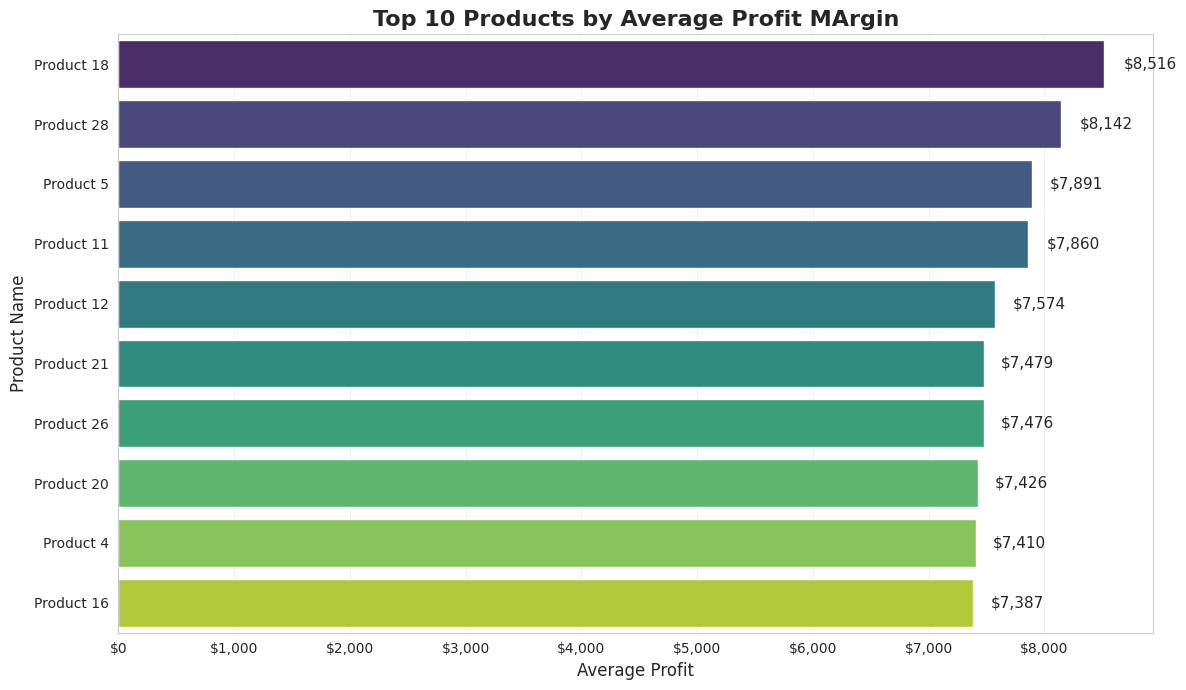

In [48]:
top_margin = (
    df.groupby('product_name')['profit'].mean().sort_values(ascending=False).head(10))
plt.figure(figsize=(12, 7))
sns.barplot(
    x=top_margin.values,
    y=top_margin.index,
    palette='viridis'
)
for i, v in enumerate(top_margin.values):
    plt.text(v * 1.02, i, f'${v:,.0f}',
             va='center', fontsize=11, fontweight='medium')

plt.title('Top 10 Products by Average Profit MArgin',
          fontsize=16,
          fontweight='bold')
plt.xlabel('Average Profit', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### INSIGHTS :

- Products 18 and 28 lead with average profit margins of approximately \$8.0–8.3 K, followed closely by Product 5 and Product 11 around \$7.9–8.0 K.

- Mid-tier performers like Products 12, 26, and 21 cluster in the \$7.7–7.8 K range, while the bottom tier (Products 4, 16, and 1) fall between \$7.4–7.6 K.

- Focusing on margin optimization strategies from top performers may help elevate overall product profitability.


# **Total Sales By US Region**

/tmp/ipykernel_4726/3053325229.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


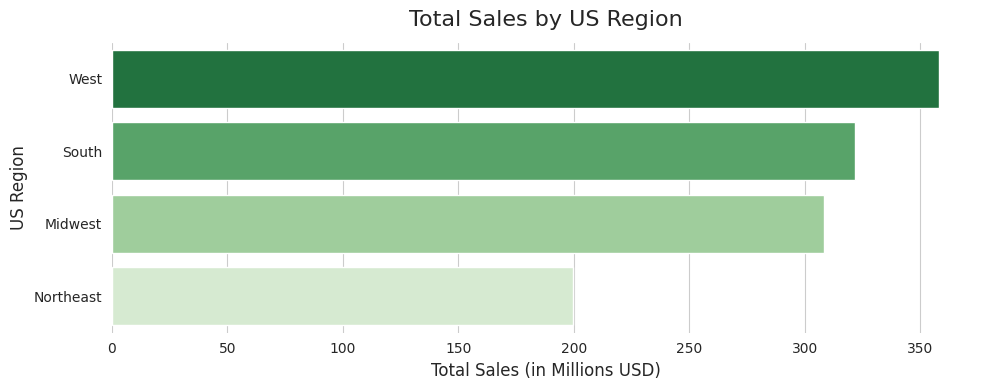

In [49]:
region_sales = (
    df
    .groupby('us_region')['revenue']
    .sum()
    .sort_values(ascending=False)
    / 1e6
)

plt.figure(figsize=(10, 4))
sns.barplot(
    x=region_sales.values,
    y=region_sales.index,
    palette='Greens_r'
)

# 3. Formatting
plt.title('Total Sales by US Region', fontsize=16, pad=12)
plt.xlabel('Total Sales (in Millions USD)', fontsize=12)
plt.ylabel('US Region', fontsize=12)
plt.xticks(rotation=0)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

### INSIGHTS :  
- **West dominates** with roughly \$360 M in sales (~35 % of total), underscoring its market leadership.  
- **South & Midwest** each contribute over \$320 M (~32 %), indicating strong, consistent demand across central regions.  
- **Northeast trails** at about \$210 M (~20 %), signaling room for growth and targeted investment.  
- **Action:** Focus on closing the Northeast gap with local promotions and strategic partnerships, while maintaining national playbook success.  


# **Correlation Matrix of Key Numeric Variables**

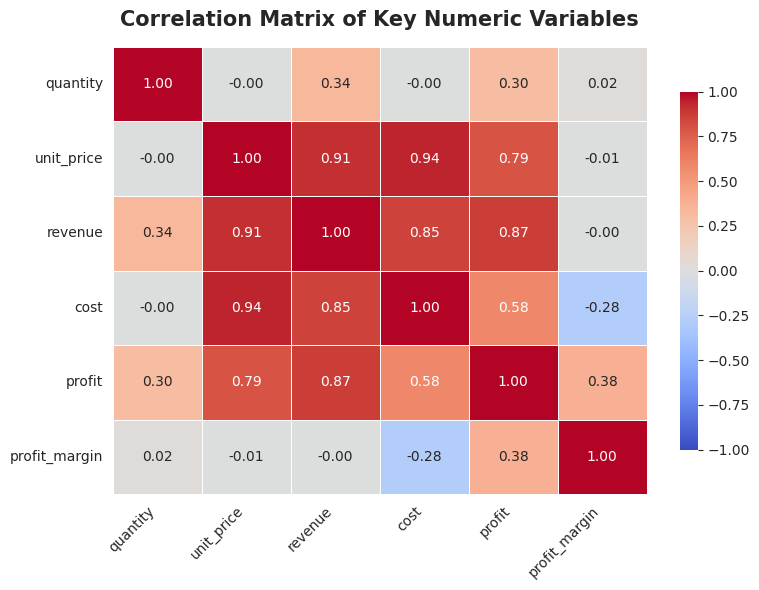

In [50]:
num_cols = ['quantity', 'unit_price', 'revenue', 'cost', 'profit', 'profit_margin']
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot_kws={"size": 10},
    cbar_kws={"shrink": 0.8}
)

plt.title('Correlation Matrix of Key Numeric Variables',
          fontsize=15,
          fontweight='bold',
          pad=15)
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **Insights**:
- unit_price ↔ revenue +0.91 Very strong positive correlation. Higher priced products drive most of the revenue.
- unit_price ↔ cost +0.94 Extremely strong. This suggests your pricing is heavily cost-based (cost-plus pricing strategy).
- revenue ↔ cost +0.85 High revenue orders also have high costs.
- cost ↔ profit_margin -0.28 Negative correlation. Higher cost products tend to have lower profit margins

# **average profit margin percentage for each channel**

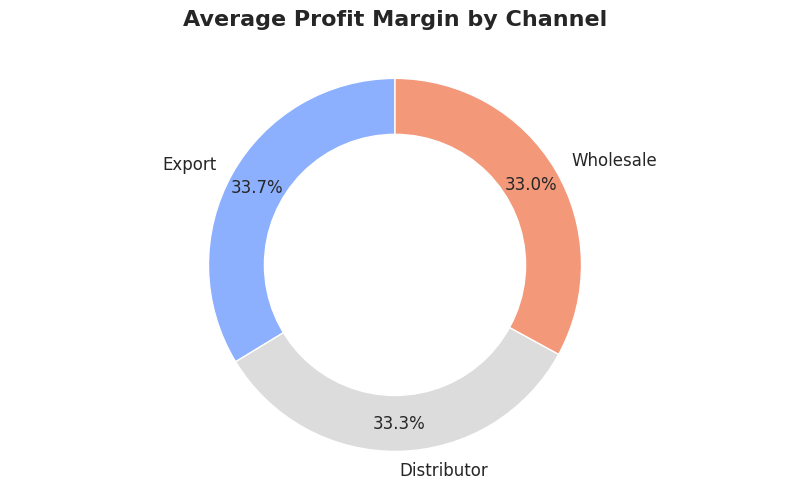

In [51]:
channel_margin = (
    df.groupby('channel')['profit_margin']
      .mean()
      .sort_values(ascending=False)
)
plt.figure(figsize=(8, 5))
colors = sns.color_palette('coolwarm', n_colors=len(channel_margin))
plt.pie(
    channel_margin.values,
    labels=channel_margin.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.85,
    textprops={'fontsize': 12, 'weight': 'medium'}
)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Add title
plt.title('Average Profit Margin by Channel',
          fontsize=16,
          fontweight='bold',
          pad=25)
plt.axis('equal')
plt.tight_layout()
plt.show()

/tmp/ipykernel_4726/2164567059.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


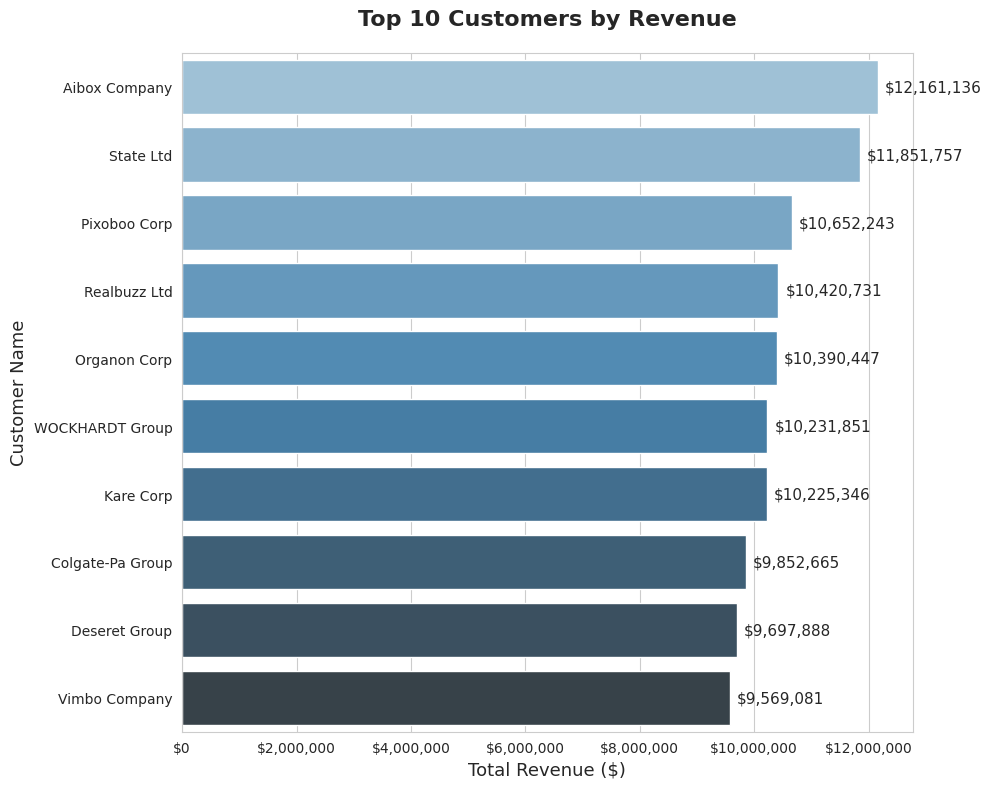

In [52]:
top_products = (
    df.groupby('customer_name')['revenue']
      .sum()
      .reset_index()
      .sort_values(by='revenue', ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=top_products,
    x='revenue',
    y='customer_name',
    palette='Blues_d'
)

for i, v in enumerate(top_products['revenue']):
    ax.text(v + (top_products['revenue'].max() * 0.01), i, f'${v:,.0f}',
            va='center', fontsize=11, fontweight='medium')
plt.title('Top 10 Customers by Revenue', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Total Revenue ($)', fontsize=13)
plt.ylabel('Customer Name', fontsize=13)

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

### INSIGHTS
- Aibox Company tops the list with \$12.5 M, followed closely by State Ltd (\$12.2 M), while the 10th-ranked Deseret Group still contributes \$9.9 M—demonstrating a tight \$10–12 M top tier.

- At the bottom, Johnson Ltd leads its group with \$5.1 M, down to BB17 Company at \$4.1 M—roughly half the top customer’s revenue.

- This steep drop from ~\$10 M+ to \$4–5 M highlights high revenue concentration among the top customers.

- Action: prioritize retention and upsell for your top ten, and launch targeted growth campaigns to elevate the lower-revenue cohort.


# **Profit Margin % vs. Unit Price**

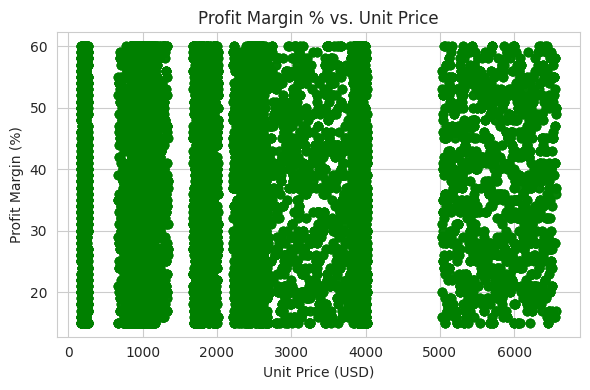

In [53]:
df['profit_margin_pct'] = (df['profit'] / df['revenue']) * 100
plt.figure(figsize=(6,4))

plt.scatter(
    df['unit_price'],
    df['profit_margin_pct'],
    alpha=0.6,
    color='green'
)

plt.title('Profit Margin % vs. Unit Price')
plt.xlabel('Unit Price (USD)')
plt.ylabel('Profit Margin (%)')
plt.tight_layout()
plt.show()

### INSIGHTS :

Profit margins are concentrated between ~18% and 60%, with no clear correlation to unit price, which spans from near \$0 to over \$6,500.

Dense horizontal bands indicate consistent margin tiers across a wide price spectrum, reflecting uniform pricing strategies.

Outliers below 18% at both low and high price points may signal cost inefficiencies or pricing issues worth deeper investigation.


# 🔍 **Key Insights**  



- **Monthly Revenue Cycle:**  
  Revenue stays stable between ≈\$23M–\$26.5M across 2014–2017, with no consistent seasonal spikes. Sharpest drop (≈\$21.2M) occurs in early 2017, indicating a possible one-time disruption.

- **Channel Mix:**  
  Wholesale: 54%. Distributors: 31%. Exports: 15% — opportunity to scale international presence.

- **Top Products (Revenue):**  
  Product 26: \$118M; Product 25: \$110M; Product 13: \$78M. Mid-tier: \$68–75M; bottom performers: \$52–57M.

- **Profit Margins:**  
  Profit margins range broadly from ≈18% to ≈60%, with no strong correlation to unit price. Dense horizontal bands suggest standardized pricing strategies across tiers.

- **Seasonal Volume:**  
  No strong monthly pattern, but slight volume uptick appears around May–June. Early 2017 dip (≈\$21.2M) may require investigation.

- **Regional Performance:**  
  California leads: ≈\$230M Revenue & 7500+ orders. Illinois/Florida/Texas: ≈\$85M–$110M & ≈3500–4500 orders. NY/Indiana: ≈\$54M & 2000+ orders.



# 💡 **Recommendations**  

1. **Outlier Strategy:** Exclude or formalize bulk-order and promotional SKUs when calculating averages.  
2. **Margin Uplift:** Apply top-product pricing levers to mid/low tiers; cut costs on underperformers.  
3. **Export Growth:** Invest in targeted overseas marketing and distributor partnerships.  
4. **Seasonal Planning:** Shift spend toward January trough and May–June peak; investigate the 2017 anomaly.  
5. **Dashboard Prep:** Build aggregated tables for time series, channel mix, and product performance for Power BI.  